# Clasificador de Anillos Galácticos — Zoobot v8 Combined
## Subclasificación: `inner` · `outer` · `inner+outer`

### Datasets combinados:
- **dataset.csv** — galaxias SDSS vía Legacy Survey DR10 (~1 329 anillos)
- **MaNGA_rings.csv** — galaxias MaNGA vía Legacy Survey DR9 (680 anillos)
- **Total combinado: ~2 009 galaxias con anillo** (sin incluir clase `none`)

### Pipeline:
1. Cargar ambos catálogos y unificar formato → lookup `id → ring_type`
2. Procesar FITS existentes (SDSS GRZ + MaNGA GRZ) → PNG por clase
3. Split estratificado train / val (80/20)
4. `GalaxyDataset` con oversample por clase (balanceo interno)
5. Fine-tuning progresivo Zoobot ConvNeXt-Nano · 3 fases · FocalLoss
6. Evaluación completa: CM, classification report, Grad-CAM, detección de anillos


---
# Parte 1: Instalación y configuración

> Ejecutar solo la primera vez. Después de instalar Zoobot, **reinstalar PyTorch con CUDA**.

In [ ]:
'''
# ============================================================
# Instalación de dependencias
# ============================================================
!pip install zoobot
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
!pip install timm plotly nbformat opencv-python-headless pytorch-grad-cam

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
'''
print("Celda de instalación (descomenta para ejecutar)")

---
# Parte 2: Imports globales

In [1]:
import os, io, re, cv2, time, glob, shutil, random, pathlib, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from astropy.io import fits
from astropy.visualization import make_lupton_rgb, ZScaleInterval, MinMaxInterval, LogStretch

from scipy import ndimage
from scipy.signal import find_peaks, savgol_filter
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import binary_closing, binary_dilation, binary_erosion, binary_opening, disk

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, roc_auc_score
)

import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from matplotlib.patches import Ellipse

import timm
import requests

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'
print("Imports completados exitosamente")

Imports completados exitosamente


---
# Parte 3: Configuración global

> **⚠️ ADAPTAR:** Modifica las rutas según tu entorno.
>
> - `CSV_SDSS` → dataset.csv (SDSS, con columnas `objID, ra, dec, anillos`)
> - `CSV_MANGA` → MaNGA_rings.csv (columnas `name, anillos, objra, objdec`)
> - `FITS_DR10_DIR` → carpeta con `<objID>_grz.fits` (Legacy Survey DR10)
> - `FITS_DR9_DIR` → carpeta con `<safe_name>_grz.fits` (Legacy Survey DR9 / MaNGA)


In [2]:
# ============================================================
# RUTAS DE ENTRADA — ADAPTAR AQUÍ
# ============================================================
CSV_SDSS         = "../Data/dataset.csv"        # SDSS (objID, ra, dec, anillos)
CSV_MANGA        = "../Data/MaNGA_rings.csv"    # MaNGA (name, anillos, objra, objdec)

# Carpetas de FITS locales ya descargados
FITS_DR10_DIR    = Path("../Images/Images_GRZ")           # SDSS → <objID>_grz.fits
FITS_DR9_DIR     = Path("../Images/MaNGA_FITS_GRZ")       # MaNGA → <safe_name>_grz.fits

# Salidas
DATA_DIR         = Path("./galaxy_images_combined")   # PNGs organizados por clase
OUTPUT_DIR       = Path("./outputs")
DATASET_NAME     = "dataset_combined_rings_3cls"      # Carpeta train/val

# ============================================================
# PARÁMETROS
# ============================================================
PIXSCALE   = 0.262          # arcsec/pixel (Legacy Survey)
SIZE       = 224
BANDS      = "grz"
TRANSFORM  = "rgi_lognorm"

# Clases
RING_CODES = {4: "inner", 8: "outer", 12: "inner+outer"}
RING_TYPE  = ["inner", "outer", "inner+outer"]
VALID_CODES = {4, 8, 12}

# Entrenamiento
IMAGE_SIZE = 224
SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Crear directorios
for d in [DATA_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
for cls_name in RING_TYPE:
    (DATA_DIR / cls_name).mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Clases: {RING_TYPE}")
print(f"FITS DR10 dir: {FITS_DR10_DIR}")
print(f"FITS DR9  dir: {FITS_DR9_DIR}")

Device: cuda
Clases: ['inner', 'outer', 'inner+outer']
FITS DR10 dir: ..\Images\Images_GRZ
FITS DR9  dir: ..\Images\MaNGA_FITS_GRZ


---
# Parte 4: Funciones auxiliares

## 4.1 Utilidades generales

In [3]:
def to_int(x, default=0):
    try: return int(float(x))
    except: return default

def safe_name(s):
    """Convierte nombre MaNGA (manga-XXXX-YYYY) a string seguro para archivo."""
    return re.sub(r'[^\w\-]', '_', str(s))

def legacy_cutout_url(ra, dec, pixscale=PIXSCALE, size=SIZE, bands=BANDS, layer="ls-dr10"):
    return (f"https://www.legacysurvey.org/viewer/fits-cutout"
            f"?ra={ra}&dec={dec}&layer={layer}"
            f"&pixscale={pixscale}&size={size}&bands={bands}")

print("Utilidades cargadas")

Utilidades cargadas


## 4.2 Transformaciones FITS → RGB

Se implementan múltiples transformaciones para las imágenes de 3 bandas (g, r, z).
La transformación por defecto es `rgi_lognorm`, que aplica normalización logarítmica
suave por banda para realzar estructuras débiles como los anillos galácticos.

In [4]:
class Transformations:
    @staticmethod
    def log_n_scale_transform(img_data, log_a=1000):
        if img_data is None or img_data.size == 0: return None
        img = img_data.astype(np.float64)
        vmin, vmax = np.nanpercentile(img, [0.5, 99.5])
        img = np.clip(img, vmin, vmax)
        if vmax > vmin: img = (img - vmin) / (vmax - vmin)
        img = np.log10(1 + log_a * img) / np.log10(1 + log_a)
        return np.clip(img * 255, 0, 255).astype(np.uint8)

    @staticmethod
    def rgi_lognorm_transform(r, g, z, log_a=1000):
        channels = []
        for band in [r, g, z]:
            ch = Transformations.log_n_scale_transform(band, log_a=log_a)
            if ch is None: return None
            channels.append(ch)
        return np.stack(channels, axis=-1)

    @staticmethod
    def rgi_stack_transform(r, g, z):
        channels = []
        for band in [r, g, z]:
            b = band.astype(np.float64)
            p1, p99 = np.nanpercentile(b, [1, 99])
            b = np.clip(b, p1, p99)
            b = (b - p1) / max(p99 - p1, 1e-10)
            channels.append((b * 255).astype(np.uint8))
        return np.stack(channels, axis=-1)

    @staticmethod
    def unsharp_transform(r, g, z, sigma=5, strength=2.0):
        channels = []
        for band in [r, g, z]:
            b = band.astype(np.float64)
            p1, p99 = np.nanpercentile(b, [1, 99])
            b = np.clip(b, p1, p99)
            b = (b - p1) / max(p99 - p1, 1e-10)
            blurred = gaussian(b, sigma=sigma)
            sharp = np.clip(b + strength * (b - blurred), 0, 1)
            channels.append((sharp * 255).astype(np.uint8))
        return np.stack(channels, axis=-1)

    @staticmethod
    def pca_transform(r, g, z):
        bands = np.stack([r.flatten(), g.flatten(), z.flatten()], axis=1).astype(np.float64)
        bands -= bands.mean(axis=0)
        _, eigenvectors = np.linalg.eigh(np.cov(bands, rowvar=False))
        pca = bands @ eigenvectors[:, ::-1]
        channels = []
        for i in range(3):
            ch = pca[:, i].reshape(r.shape)
            p1, p99 = np.nanpercentile(ch, [1, 99])
            ch = np.clip(ch, p1, p99)
            ch = (ch - p1) / max(p99 - p1, 1e-10)
            channels.append((ch * 255).astype(np.uint8))
        return np.stack(channels, axis=-1)

    @staticmethod
    def apply_transform(r_band, g_band, z_band, method="rgi_lognorm"):
        methods = {
            "rgi_stack":   lambda: Transformations.rgi_stack_transform(r_band, g_band, z_band),
            "rgi_lognorm": lambda: Transformations.rgi_lognorm_transform(r_band, g_band, z_band),
            "unsharp":     lambda: Transformations.unsharp_transform(r_band, g_band, z_band),
            "pca":         lambda: Transformations.pca_transform(r_band, g_band, z_band),
        }
        if method not in methods:
            method = "rgi_lognorm"
        try: return methods[method]()
        except Exception as e:
            print(f"Error en transformación {method}: {e}")
            return None

print("Transformaciones cargadas")

Transformaciones cargadas


---
# Parte 5: Carga y unificación de catálogos

## 5.1 Parsear ambos CSVs y construir lookups

Se cargan los dos catálogos independientemente y se construyen dos lookups:
- `sdss_id_to_class`: `objID (int64) → ring_type`
- `manga_name_to_class`: `safe_name (str) → ring_type`

Ambos se usarán para procesar sus respectivos FITS sin mezclar identificadores.

In [5]:
# ============================================================
# Catálogo SDSS (dataset.csv)
# ============================================================
df_sdss = pd.read_csv(CSV_SDSS)
df_sdss['objID'] = df_sdss['objID'].astype(np.int64)
df_sdss['anillos_int'] = df_sdss['anillos'].apply(lambda x: to_int(x, -1))
df_sdss_rings = df_sdss[df_sdss['anillos_int'].isin(VALID_CODES)].copy()
df_sdss_rings['ring_type'] = df_sdss_rings['anillos_int'].map(RING_CODES)
sdss_id_to_class = dict(zip(df_sdss_rings['objID'], df_sdss_rings['ring_type']))

print(f"=== SDSS (dataset.csv) ===")
print(f"Total: {len(df_sdss)} | Con anillo: {len(df_sdss_rings)}")
print(df_sdss_rings['ring_type'].value_counts().to_string())

# ============================================================
# Catálogo MaNGA (MaNGA_rings.csv)
# ============================================================
df_manga = pd.read_csv(CSV_MANGA)
df_manga['anillos_int'] = df_manga['anillos'].apply(lambda x: to_int(x, -1))
df_manga_rings = df_manga[df_manga['anillos_int'].isin(VALID_CODES)].copy()
df_manga_rings['ring_type'] = df_manga_rings['anillos_int'].map(RING_CODES)
df_manga_rings['safe_name'] = df_manga_rings['name'].apply(safe_name)
manga_name_to_class = dict(zip(df_manga_rings['safe_name'], df_manga_rings['ring_type']))

print(f"\n=== MaNGA (MaNGA_rings.csv) ===")
print(f"Total: {len(df_manga)} | Con anillo: {len(df_manga_rings)}")
print(df_manga_rings['ring_type'].value_counts().to_string())

# ============================================================
# Resumen combinado
# ============================================================
total_by_class = defaultdict(int)
for rt in df_sdss_rings['ring_type']: total_by_class[rt] += 1
for rt in df_manga_rings['ring_type']: total_by_class[rt] += 1

print(f"\n=== TOTAL COMBINADO ===")
grand_total = 0
for cls in RING_TYPE:
    n = total_by_class[cls]
    grand_total += n
    print(f"  {cls:15s}: {n}")
print(f"  {'TOTAL':15s}: {grand_total}")

=== SDSS (dataset.csv) ===
Total: 8528 | Con anillo: 1415
ring_type
inner          857
inner+outer    372
outer          186

=== MaNGA (MaNGA_rings.csv) ===
Total: 680 | Con anillo: 680
ring_type
inner          459
outer          161
inner+outer     60

=== TOTAL COMBINADO ===
  inner          : 1316
  outer          : 347
  inner+outer    : 432
  TOTAL          : 2095


---
# Parte 6: Procesado FITS → PNG

## 6.1 Procesar FITS SDSS (DR10) → PNG por clase

Lee archivos `<objID>_grz.fits` de `FITS_DR10_DIR`, aplica `rgi_lognorm` y guarda
en `DATA_DIR/<ring_type>/<objID>_<ring_type>.png`.

In [6]:
def process_fits_folder(fits_dir, id_to_class_fn, id_extractor_fn,
                         data_dir, transform=TRANSFORM, image_size=IMAGE_SIZE,
                         source_tag=""):
    """
    Procesa todos los *_grz.fits de fits_dir.
    id_extractor_fn(stem) -> id_key usado para lookup
    id_to_class_fn(id_key) -> ring_type o None
    """
    fits_files = sorted(Path(fits_dir).glob("*_grz.fits"))
    print(f"FITS en {fits_dir}: {len(fits_files)} [{source_tag}]")
    if not fits_files:
        print(f"  ⚠️  No se encontraron archivos — verifica la ruta: {Path(fits_dir).resolve()}")
        return

    processed = skipped_no_class = skipped_exists = errors = 0

    for fits_path in fits_files:
        try:
            id_key = id_extractor_fn(fits_path.stem)
            ring_class = id_to_class_fn(id_key)
            if ring_class is None:
                skipped_no_class += 1
                continue

            safe_stem = str(id_key).replace('+', 'plus')  # seguridad en nombres
            dest_png = Path(data_dir) / ring_class / f"{safe_stem}_{ring_class}.png"

            if dest_png.exists() and dest_png.stat().st_size > 0:
                skipped_exists += 1
                processed += 1
                continue

            with fits.open(fits_path) as hdul:
                data = hdul[0].data
                if data is None or data.ndim < 3:
                    errors += 1
                    continue
                g_band, r_band, z_band = data[0], data[1], data[2]
                img = Transformations.apply_transform(r_band, g_band, z_band, transform)

            if img is not None:
                pil_img = Image.fromarray(img)
                if pil_img.size != (image_size, image_size):
                    pil_img = pil_img.resize((image_size, image_size), Image.LANCZOS)
                pil_img.save(dest_png)
                processed += 1
            else:
                errors += 1

        except Exception as e:
            errors += 1
            if errors <= 5:
                print(f"  Error en {fits_path.name}: {e}")

    print(f"  Procesados: {processed} ({skipped_exists} ya existían) | "
          f"Sin clase: {skipped_no_class} | Errores: {errors}")


# --- Procesar FITS SDSS ---
def sdss_id_extractor(stem):
    """stem = '<objID>_grz' → int(objID)"""
    try: return int(stem.replace("_grz", ""))
    except: return None

def sdss_lookup(id_key):
    return sdss_id_to_class.get(id_key, None)

process_fits_folder(
    FITS_DR10_DIR, sdss_lookup, sdss_id_extractor,
    DATA_DIR, source_tag="SDSS DR10"
)

FITS en ..\Images\Images_GRZ: 7678 [SDSS DR10]
  Procesados: 1329 (0 ya existían) | Sin clase: 6349 | Errores: 0


## 6.2 Procesar FITS MaNGA (DR9) → PNG por clase

Lee archivos `<safe_name>_grz.fits` de `FITS_DR9_DIR` y los vuelca a la misma
carpeta `DATA_DIR` para formar un dataset unificado.

In [7]:
# --- Procesar FITS MaNGA ---
def manga_id_extractor(stem):
    """stem = '<safe_name>_grz' → safe_name str"""
    return stem.replace("_grz", "")

def manga_lookup(id_key):
    return manga_name_to_class.get(id_key, None)

process_fits_folder(
    FITS_DR9_DIR, manga_lookup, manga_id_extractor,
    DATA_DIR, source_tag="MaNGA DR9"
)

# --- Resumen final de imágenes en disco ---
print("\n=== PNGs generados en DATA_DIR ===")
total_imgs = 0
for cls_name in RING_TYPE:
    n = len(list((DATA_DIR / cls_name).glob("*.png")))
    total_imgs += n
    print(f"  {cls_name:15s}: {n}")
print(f"  {'TOTAL':15s}: {total_imgs}")

FITS en ..\Images\MaNGA_FITS_GRZ: 680 [MaNGA DR9]
  Procesados: 680 (0 ya existían) | Sin clase: 0 | Errores: 0

=== PNGs generados en DATA_DIR ===
  inner          : 1263
  outer          : 339
  inner+outer    : 407
  TOTAL          : 2009


---
# Parte 7: Análisis Exploratorio (EDA)

## 7.1 Distribución de clases y visualización de muestras

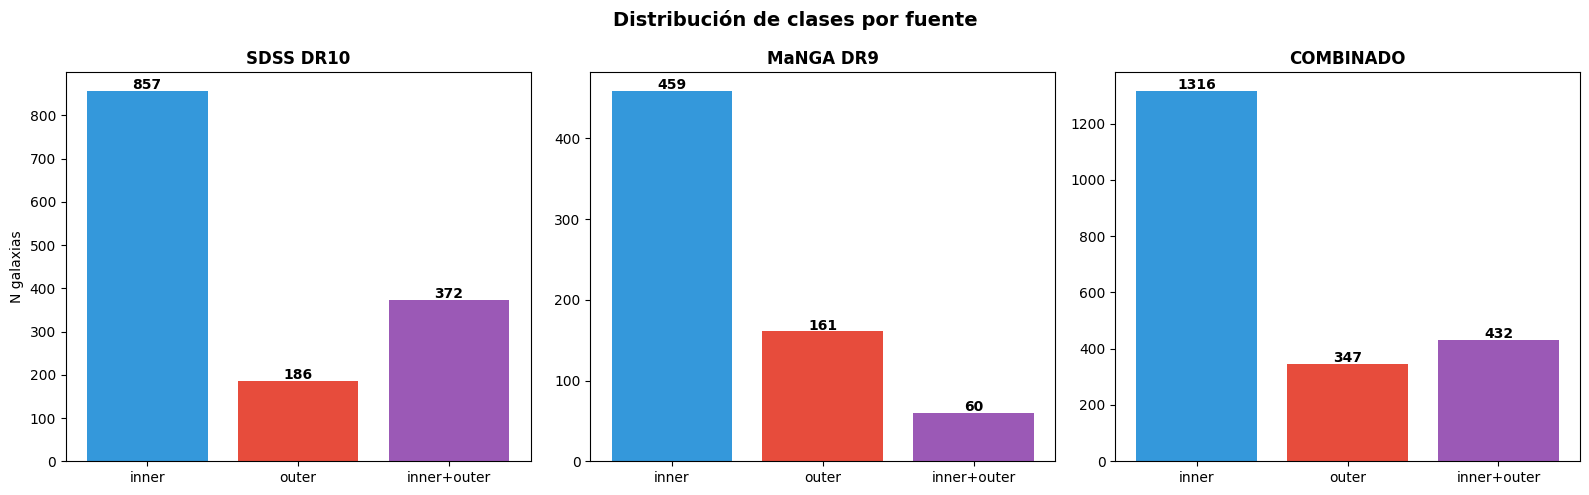

             SDSS  MaNGA  Total
inner         857    459   1316
outer         186    161    347
inner+outer   372     60    432


In [8]:
# Distribución por fuente y clase
sdss_counts = df_sdss_rings['ring_type'].value_counts()
manga_counts = df_manga_rings['ring_type'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# SDSS
colors_cls = ['#3498db', '#e74c3c', '#9b59b6']
sdss_vals = [sdss_counts.get(c, 0) for c in RING_TYPE]
manga_vals = [manga_counts.get(c, 0) for c in RING_TYPE]
combined_vals = [s + m for s, m in zip(sdss_vals, manga_vals)]

axes[0].bar(RING_TYPE, sdss_vals, color=colors_cls)
axes[0].set_title('SDSS DR10', fontweight='bold')
axes[0].set_ylabel('N galaxias')
for i, v in enumerate(sdss_vals): axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

axes[1].bar(RING_TYPE, manga_vals, color=colors_cls)
axes[1].set_title('MaNGA DR9', fontweight='bold')
for i, v in enumerate(manga_vals): axes[1].text(i, v+2, str(v), ha='center', fontweight='bold')

axes[2].bar(RING_TYPE, combined_vals, color=colors_cls)
axes[2].set_title('COMBINADO', fontweight='bold')
for i, v in enumerate(combined_vals): axes[2].text(i, v+5, str(v), ha='center', fontweight='bold')

plt.suptitle('Distribución de clases por fuente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
summary = pd.DataFrame({
    'SDSS': sdss_vals,
    'MaNGA': manga_vals,
    'Total': combined_vals
}, index=RING_TYPE)
print(summary.to_string())

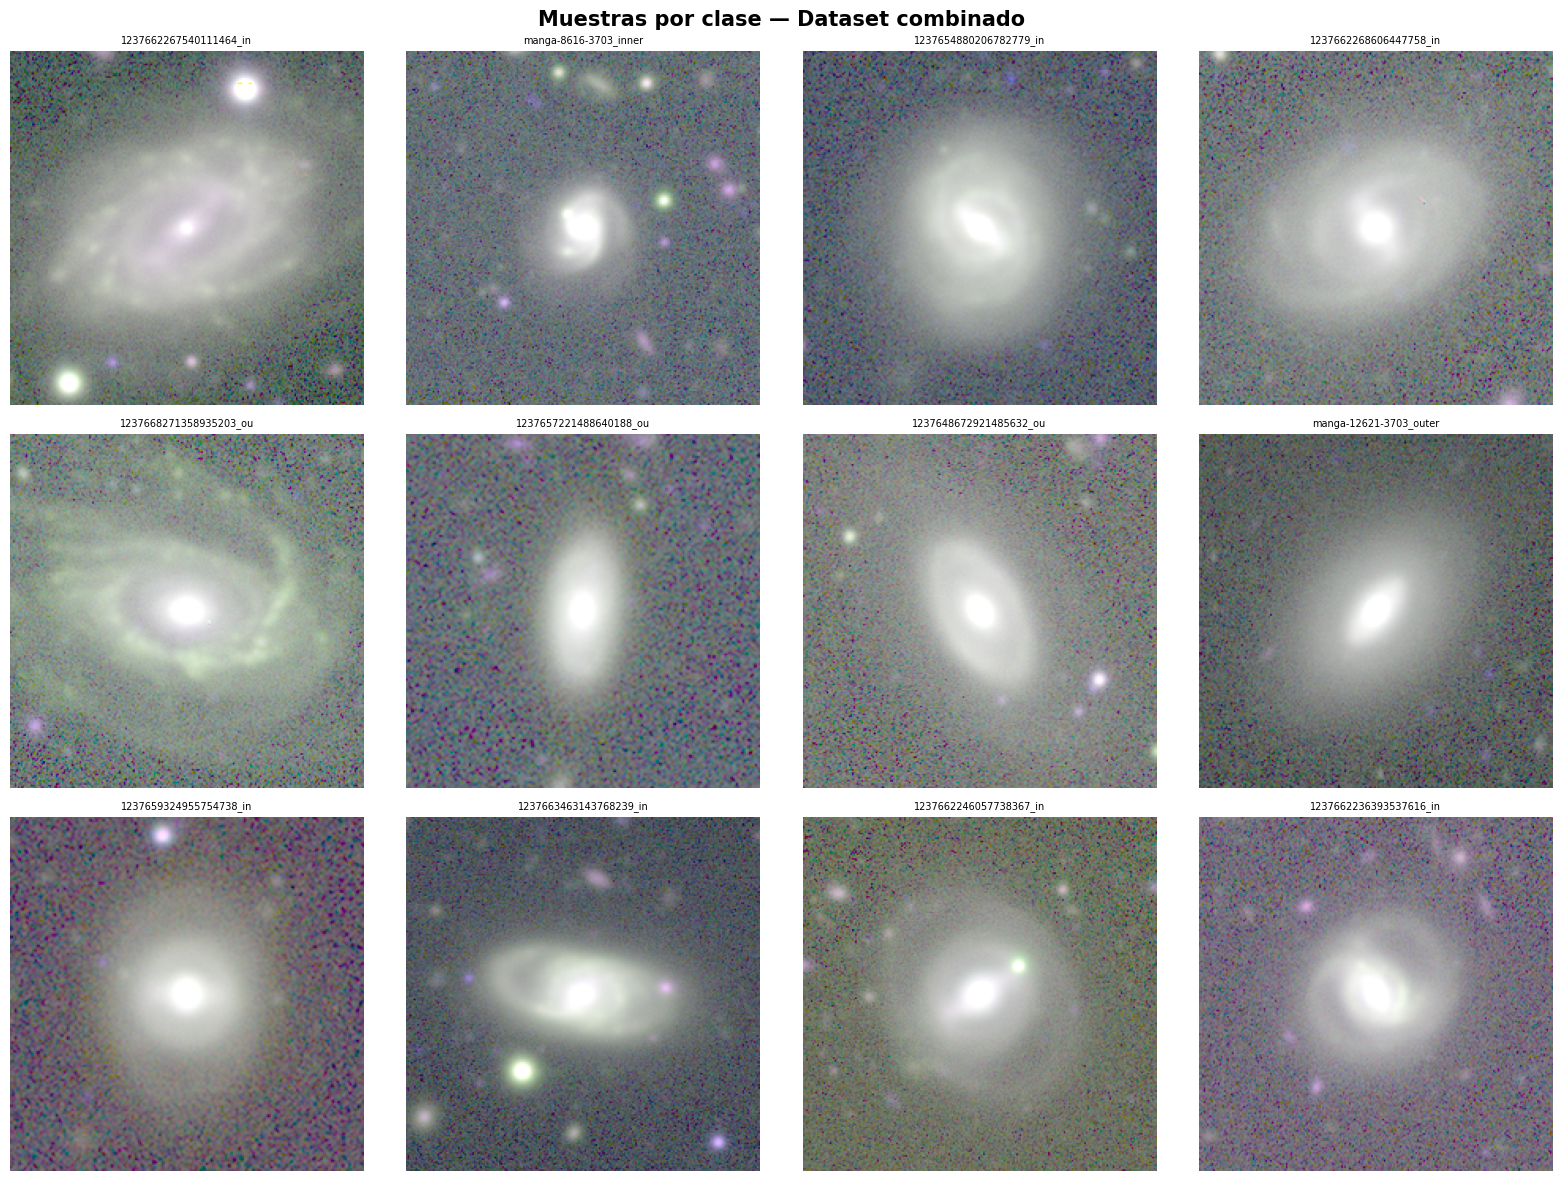

In [9]:
# Visualizar muestras de cada clase
def plot_samples_by_class(data_dir, ring_types, samples_per_class=4):
    fig, axs = plt.subplots(len(ring_types), samples_per_class,
                             figsize=(4*samples_per_class, 4*len(ring_types)))
    for i, cls in enumerate(ring_types):
        cls_dir = Path(data_dir) / cls
        imgs = list(cls_dir.glob("*.png"))
        if not imgs: continue
        samples = random.sample(imgs, min(samples_per_class, len(imgs)))
        for j, img_path in enumerate(samples):
            axs[i, j].imshow(Image.open(img_path))
            axs[i, j].axis('off')
            if j == 0:
                axs[i, j].set_ylabel(cls, fontsize=14, fontweight='bold',
                                     rotation=0, labelpad=60, va='center')
            axs[i, j].set_title(img_path.stem[:22], fontsize=7)
    plt.suptitle('Muestras por clase — Dataset combinado', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_samples_by_class(DATA_DIR, RING_TYPE)

---
# Parte 8: Preparación del dataset para entrenamiento

## 8.1 Split estratificado train / val

Se realiza un split 80/20 **manteniendo proporción por clase** (estratificado).
No se aplica sub-sampleo — el desbalanceo se maneja con `GalaxyDataset(balance=True)`
y `FocalLoss` con pesos de clase.

In [10]:
def create_dataset_folders(base_path, categories):
    base_path = Path(base_path)
    for split in ['train', 'val']:
        for cat in categories:
            (base_path / split / cat).mkdir(parents=True, exist_ok=True)

def split_dataset(source_dir, dest_base, categories, val_fraction=0.2, seed=42):
    random.seed(seed); np.random.seed(seed)
    create_dataset_folders(dest_base, categories)
    print("Creando split train/val con TODOS los datos combinados...")
    for cat in categories:
        src = Path(source_dir) / cat
        imgs = sorted(src.glob("*.png"))
        random.shuffle(imgs)
        n_val = max(10, int(len(imgs) * val_fraction))
        val_imgs, train_imgs = imgs[:n_val], imgs[n_val:]
        for img in train_imgs:
            shutil.copy2(img, Path(dest_base) / "train" / cat / img.name)
        for img in val_imgs:
            shutil.copy2(img, Path(dest_base) / "val" / cat / img.name)
        print(f"  {cat:15s}: {len(train_imgs):4d} train | {len(val_imgs):4d} val")

if Path(DATASET_NAME).exists():
    shutil.rmtree(DATASET_NAME)
split_dataset(DATA_DIR, DATASET_NAME, RING_TYPE)

Creando split train/val con TODOS los datos combinados...
  inner          : 1011 train |  252 val
  outer          :  272 train |   67 val
  inner+outer    :  326 train |   81 val


## 8.2 GalaxyDataset con oversample y augmentation

In [11]:
class GalaxyDataset(Dataset):
    """
    Dataset con balance opcional por oversample de clases minoritarias.
    En train: se replica aleatoriamente hasta alcanzar la clase mayoritaria.
    En val:   sin balance para evaluar en distribución real.
    """
    def __init__(self, root_dir, categories, transform=None, balance=True, target_count=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples, self.labels = [], []
        self.class_to_idx = {cat: i for i, cat in enumerate(categories)}
        self.idx_to_class = {i: cat for cat, i in self.class_to_idx.items()}
        class_files = {cat: list(self.root_dir.glob(f"{cat}/*.png")) for cat in categories}
        if balance:
            if target_count is None:
                target_count = max(len(f) for f in class_files.values())
            for cat, files in class_files.items():
                if len(files) < target_count:
                    extra = list(np.random.choice(files, target_count - len(files), replace=True))
                    files = files + extra
                self.samples.extend(files)
                self.labels.extend([self.class_to_idx[cat]] * len(files))
        else:
            for cat, files in class_files.items():
                self.samples.extend(files)
                self.labels.extend([self.class_to_idx[cat]] * len(files))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

    def __repr__(self):
        counts = defaultdict(int)
        for lbl in self.labels: counts[self.idx_to_class[lbl]] += 1
        return f"GalaxyDataset({len(self)} samples: {dict(counts)})"

print("GalaxyDataset definido")

GalaxyDataset definido


## 8.3 Transformaciones y DataLoaders

In [12]:
# Augmentation robusta para entrenamiento
# Las galaxias son simétricas → flip + rotación completa es correcto.
# ColorJitter suave para no destruir la señal fotométrica.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180, fill=0),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1), fill=0),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5)], p=0.3),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = GalaxyDataset(f'{DATASET_NAME}/train', RING_TYPE, transform=train_transform, balance=True)
val_dataset   = GalaxyDataset(f'{DATASET_NAME}/val',   RING_TYPE, transform=val_transform,   balance=False)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, drop_last=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

print("Train:", train_dataset)
print("Val:  ", val_dataset)

Train: GalaxyDataset(3033 samples: {'inner': 1011, 'outer': 1011, 'inner+outer': 1011})
Val:   GalaxyDataset(400 samples: {'inner': 252, 'outer': 67, 'inner+outer': 81})


---
# Parte 9: Fine-tuning de Zoobot

## 9.1 FocalLoss con label smoothing

FocalLoss reduce el peso de ejemplos fáciles y focaliza el entrenamiento en los
casos difíciles (outer y inner+outer). `label_smoothing=0.05` regulariza la confianza.
Los `alpha` (pesos por clase) se calculan automáticamente desde la distribución del loader.

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        n_classes = inputs.size(1)
        smooth = torch.zeros_like(inputs).scatter_(1, targets.unsqueeze(1), 1.0)
        smooth = smooth * (1 - self.label_smoothing) + self.label_smoothing / n_classes
        log_probs = F.log_softmax(inputs, dim=1)
        probs     = torch.exp(log_probs)
        focal_weight = (1 - probs) ** self.gamma
        loss = -focal_weight * smooth * log_probs
        if self.alpha is not None:
            loss = loss * self.alpha.to(inputs.device).unsqueeze(0)
        return loss.sum(dim=1).mean()

print("FocalLoss definido")

FocalLoss definido


## 9.2 ZoobotRingSubclassifier (ConvNeXt-Nano backbone)

Encoder preentrenado de Zoobot (Galaxy Zoo) + head personalizado de 2 capas:
```
BatchNorm → Dropout(0.4) → Linear(640→128) → GELU → BatchNorm → Dropout(0.2) → Linear(128→3)
```

El método `set_phase` controla el descongelado progresivo del encoder:
- **Phase 1**: Solo head (~84k params)
- **Phase 2**: Head + últimas 2 capas del encoder
- **Phase 3**: Todo el encoder (fine-tuning completo)

In [14]:
class ZoobotRingSubclassifier(nn.Module):
    def __init__(self, n_classes=3, dropout=0.4,
                 encoder_name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano'):
        super().__init__()
        self.device = DEVICE
        self.ring_type = RING_TYPE
        self.n_classes = n_classes
        print(f'Cargando encoder: {encoder_name}')
        self.encoder = timm.create_model(encoder_name, pretrained=True, num_classes=0)
        with torch.no_grad():
            dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            encoder_dim = self.encoder(dummy).shape[-1]
        print(f'Encoder dim: {encoder_dim}')
        self.head = nn.Sequential(
            nn.BatchNorm1d(encoder_dim), nn.Dropout(p=dropout),
            nn.Linear(encoder_dim, 128), nn.GELU(),
            nn.BatchNorm1d(128), nn.Dropout(p=dropout * 0.5),
            nn.Linear(128, n_classes),
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
        self.criterion = FocalLoss(gamma=2.0, label_smoothing=0.05)
        self.to(self.device)

    def forward(self, x):
        features = self.encoder(x)
        if features.dim() > 2:
            features = F.adaptive_avg_pool2d(features, 1).flatten(1)
        return self.head(features)

    def save_model(self, path):
        torch.save(self.state_dict(), path)
        print(f'Modelo guardado: {path}')

    def load_model(self, path):
        self.load_state_dict(torch.load(path, map_location=self.device, weights_only=True))
        print(f'Modelo cargado: {path}')

    def __str__(self):
        total = sum(p.numel() for p in self.parameters())
        return f'ZoobotRingSubclassifier | Classes: {self.ring_type} | Params: {total:,}'

    def set_phase(self, phase):
        for param in self.parameters(): param.requires_grad = False
        if phase >= 1:
            for param in self.head.parameters(): param.requires_grad = True
        if phase >= 2:
            for child in list(self.encoder.children())[-2:]:
                for param in child.parameters(): param.requires_grad = True
        if phase >= 3:
            for param in self.encoder.parameters(): param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'  Phase {phase}: {trainable:,}/{total:,} ({100*trainable/total:.1f}%)')

    def _compute_class_weights(self, loader):
        counts = defaultdict(int)
        for _, labels in loader:
            for l in labels.numpy(): counts[l] += 1
        total = sum(counts.values()); n = len(counts)
        w = torch.zeros(n)
        for idx, count in counts.items(): w[idx] = total / (n * count)
        return w / w.mean()

    def _validate(self, val_loader):
        self.eval()
        all_preds, all_labels = [], []
        running_loss, total = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                total += images.size(0)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        report = classification_report(all_labels, all_preds,
                    target_names=self.ring_type, output_dict=True, zero_division=0)
        return {'loss': running_loss/total, 'acc': report['accuracy'],
                'macro_f1': report['macro avg']['f1-score']}

    def train_model(self, train_loader, val_loader, epochs=15, phase=1, lr=1e-4, patience=10):
        self.to(self.device)
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'macro_f1': []}
        print(f'\n{"="*60}')
        print(f' Phase {phase} | {epochs} epochs | LR={lr}')
        print(f'{"="*60}')
        self.set_phase(phase)
        cw = self._compute_class_weights(train_loader)
        self.criterion.alpha = cw
        print(f'  Weights: { {self.ring_type[k]: f"{v:.2f}" for k, v in enumerate(cw.tolist())} }')
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.parameters()), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-7)
        best_f1, patience_counter = 0.0, 0
        best_path = OUTPUT_DIR / f'best_combined_phase{phase}.pt'
        for epoch in range(epochs):
            self.train()
            running_loss, correct, total = 0.0, 0, 0
            for images, labels in train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                optimizer.step()
                running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
            e_loss, e_acc = running_loss/total, correct/total
            history['train_loss'].append(e_loss); history['train_acc'].append(e_acc)
            val_m = self._validate(val_loader)
            history['val_loss'].append(val_m['loss']); history['val_acc'].append(val_m['acc'])
            history['macro_f1'].append(val_m['macro_f1'])
            scheduler.step(val_m['macro_f1'])
            lr_now = optimizer.param_groups[0]['lr']
            mark = ' ✓' if val_m['macro_f1'] > best_f1 else ''
            print(f'  E{epoch+1:02d}/{epochs} | TL {e_loss:.4f} TA {e_acc:.3f} | '
                  f'VL {val_m["loss"]:.4f} VA {val_m["acc"]:.3f} | '
                  f'MF1 {val_m["macro_f1"]:.4f} | lr {lr_now:.2e}{mark}')
            if val_m['macro_f1'] > best_f1:
                best_f1 = val_m['macro_f1']
                self.save_model(str(best_path))
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f'  Early stopping (patience={patience})')
                    break
        print(f'  Mejor MF1 phase {phase}: {best_f1:.4f} → {best_path}')
        return history

    def evaluate(self, val_loader, plot=True):
        self.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(self.device)
                outputs = self(images)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())
        print('\n' + '='*60)
        print(classification_report(all_labels, all_preds, target_names=self.ring_type))
        report = classification_report(all_labels, all_preds,
                    target_names=self.ring_type, output_dict=True)
        if plot:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            cm = confusion_matrix(all_labels, all_preds)
            sns.heatmap(cm, annot=True, fmt='d', xticklabels=self.ring_type,
                        yticklabels=self.ring_type, cmap='Blues', ax=axes[0])
            axes[0].set_title('Confusion Matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
            cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=self.ring_type,
                        yticklabels=self.ring_type, cmap='YlOrRd', ax=axes[1])
            axes[1].set_title('Normalizada')
            plt.suptitle('Evaluación — Dataset combinado SDSS + MaNGA', fontsize=13, fontweight='bold')
            plt.tight_layout(); plt.show()
        mf1 = report['macro avg']['f1-score']; wf1 = report['weighted avg']['f1-score']
        print(f'\n  Macro F1: {mf1:.4f} | Weighted F1: {wf1:.4f}')
        return report

model = ZoobotRingSubclassifier(n_classes=3, dropout=0.4)
print(model)

Cargando encoder: hf_hub:mwalmsley/zoobot-encoder-convnext_nano


Encoder dim: 640
ZoobotRingSubclassifier | Classes: ['inner', 'outer', 'inner+outer'] | Params: 15,036,531


## 9.3 Entrenamiento progresivo — 3 fases

| Fase | Parámetros descongelados | LR | Épocas |
|------|--------------------------|-----|--------|
| 1 | Solo head | 5e-4 | 15 |
| 2 | Head + últimas 2 capas encoder | 1e-4 | 15 |
| 3 | Todo el encoder (fine-tuning completo) | 2e-5 | 10 |

In [15]:
# ── Fase 1: Solo Head ──────────────────────────────────────────────
history_f1 = model.train_model(train_dataloader, val_dataloader,
    epochs=15, phase=1, lr=5e-4, patience=8)


 Phase 1 | 15 epochs | LR=0.0005
  Phase 1: 83,971/15,036,531 (0.6%)
  Weights: {'inner': '1.00', 'outer': '1.00', 'inner+outer': '1.00'}
  E01/15 | TL 0.8498 TA 0.481 | VL 0.6046 VA 0.540 | MF1 0.5314 | lr 5.00e-04 ✓
Modelo guardado: outputs\best_combined_phase1.pt
  E02/15 | TL 0.6734 TA 0.516 | VL 0.4884 VA 0.590 | MF1 0.5726 | lr 5.00e-04 ✓
Modelo guardado: outputs\best_combined_phase1.pt
  E03/15 | TL 0.5524 TA 0.538 | VL 0.4431 VA 0.573 | MF1 0.5639 | lr 5.00e-04
  E04/15 | TL 0.4890 TA 0.564 | VL 0.4177 VA 0.603 | MF1 0.5843 | lr 5.00e-04 ✓
Modelo guardado: outputs\best_combined_phase1.pt
  E05/15 | TL 0.4693 TA 0.555 | VL 0.4082 VA 0.593 | MF1 0.5731 | lr 5.00e-04
  E06/15 | TL 0.4324 TA 0.584 | VL 0.4113 VA 0.595 | MF1 0.5815 | lr 5.00e-04
  E07/15 | TL 0.4307 TA 0.580 | VL 0.3715 VA 0.615 | MF1 0.5911 | lr 5.00e-04 ✓
Modelo guardado: outputs\best_combined_phase1.pt
  E08/15 | TL 0.4079 TA 0.593 | VL 0.3868 VA 0.603 | MF1 0.5878 | lr 5.00e-04
  E09/15 | TL 0.3937 TA 0.593 | V

In [16]:
# ── Fase 2: Head + encoder capas superiores ────────────────────────
history_f2 = model.train_model(train_dataloader, val_dataloader,
    epochs=15, phase=2, lr=1e-4, patience=8)


 Phase 2 | 15 epochs | LR=0.0001
  Phase 2: 85,251/15,036,531 (0.6%)
  Weights: {'inner': '1.00', 'outer': '1.00', 'inner+outer': '1.00'}
  E01/15 | TL 0.3536 TA 0.626 | VL 0.3556 VA 0.647 | MF1 0.6241 | lr 1.00e-04 ✓
Modelo guardado: outputs\best_combined_phase2.pt
  E02/15 | TL 0.3519 TA 0.628 | VL 0.3579 VA 0.637 | MF1 0.6157 | lr 1.00e-04
  E03/15 | TL 0.3449 TA 0.642 | VL 0.3634 VA 0.620 | MF1 0.6011 | lr 1.00e-04
  E04/15 | TL 0.3457 TA 0.646 | VL 0.3612 VA 0.627 | MF1 0.6084 | lr 1.00e-04
  E05/15 | TL 0.3443 TA 0.629 | VL 0.3634 VA 0.623 | MF1 0.6081 | lr 1.00e-04
  E06/15 | TL 0.3458 TA 0.654 | VL 0.3644 VA 0.620 | MF1 0.6020 | lr 5.00e-05
  E07/15 | TL 0.3477 TA 0.652 | VL 0.3612 VA 0.627 | MF1 0.6084 | lr 5.00e-05
  E08/15 | TL 0.3448 TA 0.647 | VL 0.3533 VA 0.625 | MF1 0.6035 | lr 5.00e-05
  E09/15 | TL 0.3466 TA 0.645 | VL 0.3557 VA 0.632 | MF1 0.6112 | lr 5.00e-05
  Early stopping (patience=8)
  Mejor MF1 phase 2: 0.6241 → outputs\best_combined_phase2.pt


In [17]:
# ── Fase 3: Fine-tuning completo ────────────────────────────────────
# LR muy bajo para no destruir el preentrenamiento de Zoobot
history_f3 = model.train_model(train_dataloader, val_dataloader,
    epochs=10, phase=3, lr=2e-5, patience=6)


 Phase 3 | 10 epochs | LR=2e-05
  Phase 3: 15,036,531/15,036,531 (100.0%)
  Weights: {'inner': '1.00', 'outer': '1.00', 'inner+outer': '1.00'}
  E01/10 | TL 0.3258 TA 0.673 | VL 0.3663 VA 0.627 | MF1 0.6104 | lr 2.00e-05 ✓
Modelo guardado: outputs\best_combined_phase3.pt
  E02/10 | TL 0.2992 TA 0.718 | VL 0.3629 VA 0.657 | MF1 0.6396 | lr 2.00e-05 ✓
Modelo guardado: outputs\best_combined_phase3.pt
  E03/10 | TL 0.2876 TA 0.724 | VL 0.3529 VA 0.660 | MF1 0.6341 | lr 2.00e-05
  E04/10 | TL 0.2740 TA 0.751 | VL 0.3539 VA 0.655 | MF1 0.6376 | lr 2.00e-05
  E05/10 | TL 0.2666 TA 0.749 | VL 0.3383 VA 0.670 | MF1 0.6414 | lr 2.00e-05 ✓
Modelo guardado: outputs\best_combined_phase3.pt
  E06/10 | TL 0.2509 TA 0.779 | VL 0.3257 VA 0.708 | MF1 0.6708 | lr 2.00e-05 ✓
Modelo guardado: outputs\best_combined_phase3.pt
  E07/10 | TL 0.2444 TA 0.783 | VL 0.3578 VA 0.670 | MF1 0.6424 | lr 2.00e-05
  E08/10 | TL 0.2369 TA 0.789 | VL 0.3280 VA 0.710 | MF1 0.6748 | lr 2.00e-05 ✓
Modelo guardado: outputs\b

---
# Parte 10: Evaluación

## 10.1 Curvas de entrenamiento

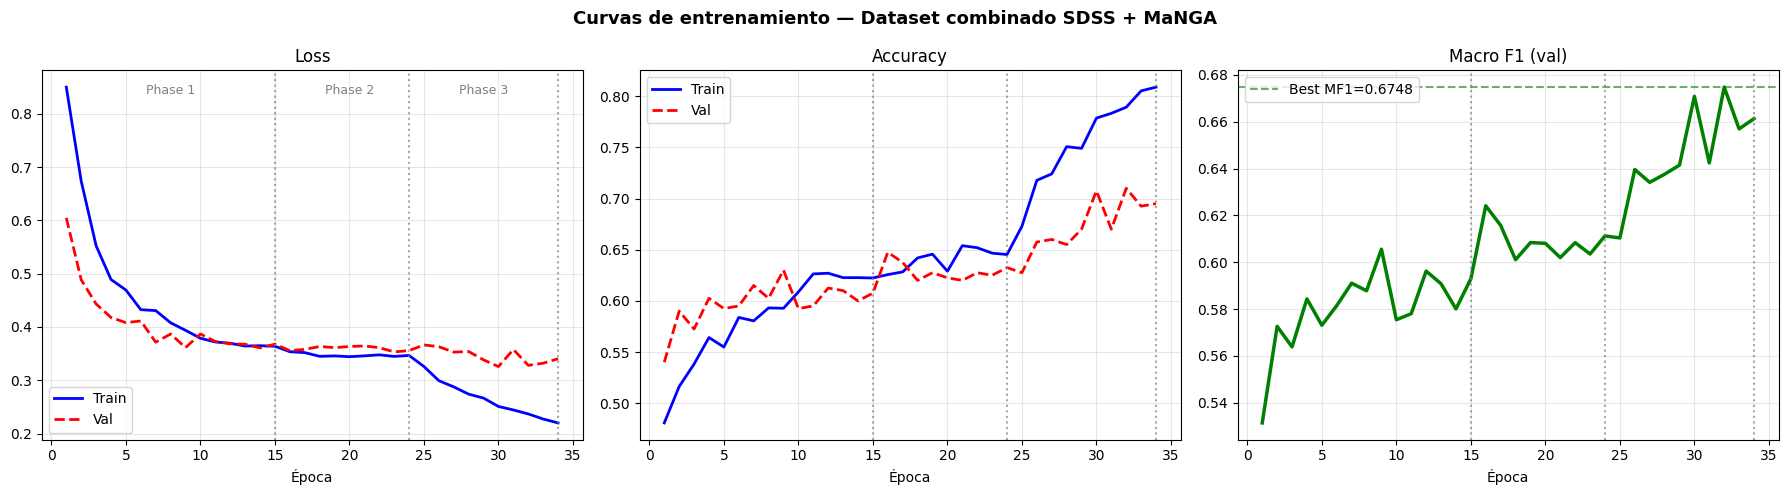

In [18]:
def plot_training_history(histories, labels):
    """Grafica loss, accuracy y macro-F1 de múltiples fases."""
    all_loss_train, all_loss_val = [], []
    all_acc_train, all_acc_val = [], []
    all_f1 = []
    for h in histories:
        all_loss_train.extend(h['train_loss'])
        all_loss_val.extend(h['val_loss'])
        all_acc_train.extend(h['train_acc'])
        all_acc_val.extend(h['val_acc'])
        all_f1.extend(h['macro_f1'])

    epochs = range(1, len(all_loss_train) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, all_loss_train, 'b-', label='Train', lw=2)
    axes[0].plot(epochs, all_loss_val, 'r--', label='Val', lw=2)
    axes[0].set_title('Loss'); axes[0].set_xlabel('Época')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, all_acc_train, 'b-', label='Train', lw=2)
    axes[1].plot(epochs, all_acc_val, 'r--', label='Val', lw=2)
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Época')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs, all_f1, 'g-', lw=2.5)
    axes[2].axhline(max(all_f1), color='green', ls='--', alpha=0.6,
                    label=f'Best MF1={max(all_f1):.4f}')
    axes[2].set_title('Macro F1 (val)'); axes[2].set_xlabel('Época')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    # Marcar cambios de fase
    cumlen = 0
    for h, lbl in zip(histories, labels):
        cumlen += len(h['train_loss'])
        for ax in axes:
            ax.axvline(cumlen, color='gray', ls=':', alpha=0.7)
        axes[0].text(cumlen - len(h['train_loss'])//2, axes[0].get_ylim()[1]*0.95,
                     lbl, ha='center', fontsize=9, color='gray')

    plt.suptitle('Curvas de entrenamiento — Dataset combinado SDSS + MaNGA',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(
    [history_f1, history_f2, history_f3],
    ['Phase 1', 'Phase 2', 'Phase 3']
)

## 10.2 Evaluación completa — Confusion Matrix + Report

Cargando mejor checkpoint: outputs\best_combined_phase3.pt
Modelo cargado: outputs\best_combined_phase3.pt

              precision    recall  f1-score   support

       inner       0.88      0.69      0.78       252
       outer       0.52      0.72      0.60        67
 inner+outer       0.56      0.77      0.65        81

    accuracy                           0.71       400
   macro avg       0.65      0.72      0.67       400
weighted avg       0.76      0.71      0.72       400



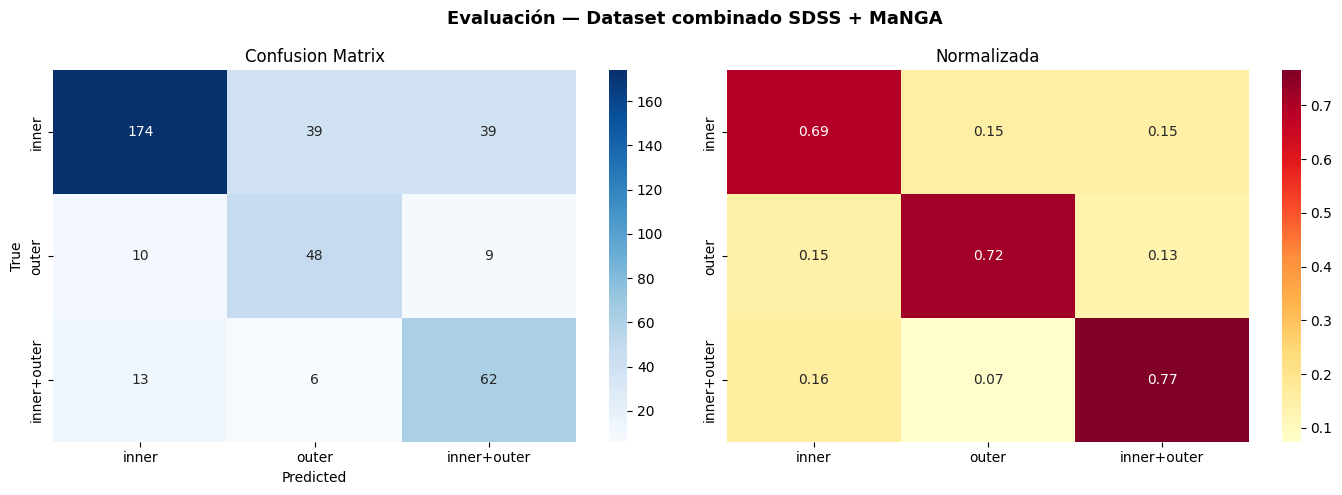


  Macro F1: 0.6748 | Weighted F1: 0.7203


In [19]:
# Cargar el mejor checkpoint antes de evaluar
# (opcional: si quieres evaluar el estado actual del modelo, omite estas líneas)
best_ckpt = max(OUTPUT_DIR.glob('best_combined_phase*.pt'),
                key=lambda p: p.stat().st_mtime, default=None)
if best_ckpt:
    print(f'Cargando mejor checkpoint: {best_ckpt}')
    model.load_model(str(best_ckpt))

report = model.evaluate(val_dataloader, plot=True)

---
# Parte 11: Visualización — Grad-CAM + Detección de anillos

## 11.1 Funciones morfológicas

Se reutilizan las funciones del notebook Stage2 (que produce buenas visualizaciones):
- `compute_radial_profile`: perfil de intensidad mediana por radio
- `fit_ellipse_at_radius`: ajuste de elipse a la galaxia en un radio dado
- `get_galaxy_shape`: orientación y razón axial de la galaxia
- `detect_bar_pca`: detección de barra galáctica por PCA
- `detect_rings_v3`: detección completa de anillos inner/outer

In [20]:
def compute_radial_profile(img, cy, cx, n_bins=60):
    h, w = img.shape
    y_idx, x_idx = np.mgrid[0:h, 0:w]
    r = np.sqrt((x_idx - cx)**2 + (y_idx - cy)**2)
    max_r = min(cy, cx, h - cy, w - cx)
    bin_edges = np.linspace(0, max_r, n_bins + 1)
    profile = []
    for i in range(len(bin_edges) - 1):
        mask = (r >= bin_edges[i]) & (r < bin_edges[i + 1])
        if mask.sum() > 0:
            profile.append(float(np.median(img[mask])))
        else:
            profile.append(0.0)
    radii_arc = (bin_edges[:-1] + np.diff(bin_edges) / 2) * PIXSCALE
    return radii_arc, np.array(profile)


def fit_ellipse_at_radius(img, cy, cx, radius_px, galaxy_angle, galaxy_ratio):
    h, w = img.shape
    ring_mask = np.zeros((h, w), dtype=np.uint8)
    thickness = max(3, int(radius_px * 0.15))
    for dr in range(-thickness, thickness + 1):
        r = radius_px + dr
        if r <= 0: continue
        b = max(2, int(r * galaxy_ratio))
        cv2.ellipse(ring_mask, (int(cx), int(cy)), (int(r), int(b)),
                    galaxy_angle, 0, 360, 1, -1)
    contours, _ = cv2.findContours(ring_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if contours:
        pts = np.vstack(contours).squeeze()
        if len(pts) >= 5:
            try:
                ellipse = cv2.fitEllipse(pts)
                (ex, ey), (ma, mi), angle = ellipse
                return float(max(ma, mi)) / 2, float(min(ma, mi)) / 2, float(angle)
            except:
                pass
    b = max(2, int(radius_px * galaxy_ratio))
    return float(radius_px), float(b), float(galaxy_angle)


def get_galaxy_shape(img, cy, cx):
    h, w = img.shape
    y_idx, x_idx = np.mgrid[0:h, 0:w]
    r_eff = max(h, w) * 0.25
    mask = ((x_idx - cx)**2 + (y_idx - cy)**2) < r_eff**2
    weights = img[mask].flatten()
    if weights.sum() < 1e-10:
        return 0.0, 0.75, r_eff
    ys, xs = y_idx[mask].flatten(), x_idx[mask].flatten()
    X = np.stack([xs - cx, ys - cy], axis=1).astype(float)
    cov = np.cov(X.T, aweights=np.clip(weights, 0, None))
    vals, vecs = np.linalg.eigh(cov)
    idx = vals.argsort()[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    angle = float(np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0])))
    ratio = float(np.sqrt(abs(vals[1]) / (abs(vals[0]) + 1e-10)))
    ratio = np.clip(ratio, 0.3, 1.0)
    r_eff_est = float(np.sqrt(abs(vals[0])))
    return angle, ratio, max(r_eff_est, 8.0)


def detect_bar_pca(img, cy, cx, inner_frac=0.5):
    h, w = img.shape
    inner_r = min(cy, cx, h - cy, w - cx) * inner_frac
    y_idx, x_idx = np.mgrid[0:h, 0:w]
    mask = ((x_idx - cx)**2 + (y_idx - cy)**2) < inner_r**2
    weights = np.clip(img[mask], 0, None)
    if weights.sum() < 1e-10:
        return 0.0, 0.0, 0.0
    ys, xs = y_idx[mask].astype(float), x_idx[mask].astype(float)
    X = np.stack([xs - cx, ys - cy], axis=1)
    cov = np.cov(X.T, aweights=weights + 1e-10)
    vals, vecs = np.linalg.eigh(cov)
    idx = vals.argsort()[::-1]
    vals = vals[idx]
    bar_angle = float(np.degrees(np.arctan2(vecs[1, idx[0]], vecs[0, idx[0]])))
    bar_len_arc = float(np.sqrt(abs(vals[0])) * 2 * PIXSCALE)
    bar_strength = float(np.sqrt(abs(vals[0]) / (abs(vals[1]) + 1e-10)))
    return bar_angle, bar_len_arc, bar_strength


def detect_rings_v3(img_rgb, predicted_class):
    """
    Detección de anillos usando perfil radial + ajuste de elipses.
    Retorna: (list[dict_ring], (cy, cx))
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray_f = gray.astype(np.float32) / 255.0
    h, w = gray_f.shape
    cy, cx = h // 2, w // 2

    # Refinar centro por centroide ponderado
    radius_search = min(h, w) // 4
    y_idx, x_idx = np.mgrid[0:h, 0:w]
    center_mask = ((x_idx - cx)**2 + (y_idx - cy)**2) < radius_search**2
    region = gray_f * center_mask
    total_weight = region.sum()
    if total_weight > 1e-6:
        cy = int(np.sum(y_idx * region) / total_weight)
        cx = int(np.sum(x_idx * region) / total_weight)
        cy = int(np.clip(cy, h * 0.2, h * 0.8))
        cx = int(np.clip(cx, w * 0.2, w * 0.8))

    smoothed = gaussian(gray_f, sigma=2.0)
    galaxy_angle, galaxy_ratio, r_eff = get_galaxy_shape(gray_f, cy, cx)
    max_r = min(cy, cx, h - cy, w - cx)
    max_ring_r = min(max_r * 0.85, r_eff * 1.5)

    radii_arc, profile = compute_radial_profile(gray_f, cy, cx)
    win = max(5, len(profile) // 8)
    if win % 2 == 0: win += 1
    try:    profile_sm = savgol_filter(profile, win, 3)
    except: profile_sm = profile
    skip = max(2, int(len(profile_sm) * 0.05))
    search = profile_sm[skip:]
    dyn = search.max() - search.min()
    peaks, _ = find_peaks(search, distance=max(4, len(search) // 8),
                          prominence=max(dyn * 0.02, 1e-4), width=2)
    peak_pxs = [radii_arc[p + skip] / PIXSCALE for p in peaks]

    ellipses = []
    for rpx in peak_pxs:
        rpx = int(rpx)
        if rpx < 5 or rpx > max_ring_r: continue
        sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, rpx, galaxy_angle, galaxy_ratio)
        ellipses.append({'semi_a': sa, 'semi_b': sb, 'angle': ang,
                         'radius_px': rpx, 'detected': True})
    ellipses.sort(key=lambda e: e['radius_px'])
    ellipses = [e for e in ellipses if 5 < e['radius_px'] < max_ring_r]

    result = []
    if predicted_class == 'inner':
        if ellipses:
            e = ellipses[0].copy(); e['type'] = 'Inner'; result = [e]
        else:
            r = max(8, int(r_eff * 0.30))
            sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, r, galaxy_angle, galaxy_ratio)
            result = [{'semi_a': sa, 'semi_b': sb, 'angle': ang,
                       'radius_px': r, 'type': 'Inner', 'detected': False}]
    elif predicted_class == 'outer':
        if ellipses:
            e = ellipses[-1].copy(); e['type'] = 'Outer'; result = [e]
        else:
            r = max(15, int(min(r_eff * 0.9, max_ring_r * 0.8)))
            sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, r, galaxy_angle, galaxy_ratio)
            result = [{'semi_a': sa, 'semi_b': sb, 'angle': ang,
                       'radius_px': r, 'type': 'Outer', 'detected': False}]
    else:  # inner+outer
        if len(ellipses) >= 2:
            ie, oe = ellipses[0].copy(), ellipses[-1].copy()
            if oe['radius_px'] > ie['radius_px'] * 1.5:
                ie['type'] = 'Inner'; oe['type'] = 'Outer'
                result = [ie, oe]
            else:
                ie['type'] = 'Inner'
                r_out = int(min(max(ie['radius_px'] * 2.2, r_eff * 0.9), max_ring_r))
                sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, r_out, galaxy_angle, galaxy_ratio)
                result = [ie, {'semi_a': sa, 'semi_b': sb, 'angle': ang,
                               'radius_px': r_out, 'type': 'Outer', 'detected': False}]
        elif len(ellipses) == 1:
            e = ellipses[0]
            if e['radius_px'] < r_eff * 0.5:
                e['type'] = 'Inner'
                r_out = int(min(max(e['radius_px'] * 2.5, r_eff * 0.85), max_ring_r))
                sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, r_out, galaxy_angle, galaxy_ratio)
                result = [e, {'semi_a': sa, 'semi_b': sb, 'angle': ang,
                              'radius_px': r_out, 'type': 'Outer', 'detected': False}]
            else:
                e['type'] = 'Outer'
                r_in = max(8, int(e['radius_px'] * 0.35))
                sa, sb, ang = fit_ellipse_at_radius(smoothed, cy, cx, r_in, galaxy_angle, galaxy_ratio)
                result = [{'semi_a': sa, 'semi_b': sb, 'angle': ang,
                           'radius_px': r_in, 'type': 'Inner', 'detected': False}, e]
        else:
            r_in = max(8, int(r_eff * 0.35))
            r_out = int(min(r_eff * 0.9, max_ring_r))
            sa_i, sb_i, ai = fit_ellipse_at_radius(smoothed, cy, cx, r_in, galaxy_angle, galaxy_ratio)
            sa_o, sb_o, ao = fit_ellipse_at_radius(smoothed, cy, cx, r_out, galaxy_angle, galaxy_ratio)
            result = [
                {'semi_a': sa_i, 'semi_b': sb_i, 'angle': ai,
                 'radius_px': r_in, 'type': 'Inner', 'detected': False},
                {'semi_a': sa_o, 'semi_b': sb_o, 'angle': ao,
                 'radius_px': r_out, 'type': 'Outer', 'detected': False},
            ]
    return result, (cy, cx)

print("Funciones morfológicas cargadas")

Funciones morfológicas cargadas


## 11.2 Visualización de muestras con detección de anillos

Visualizando muestras con detección de anillos...


 Clase: INNER


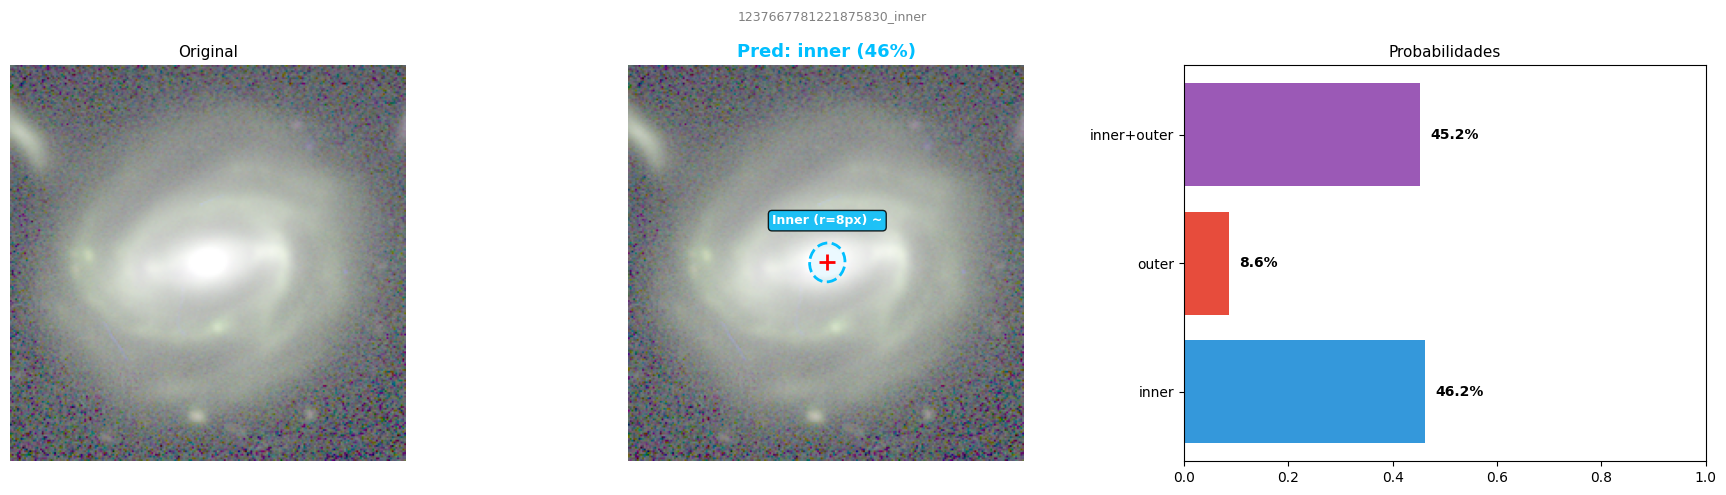

  Inner  (estimado): r=8px


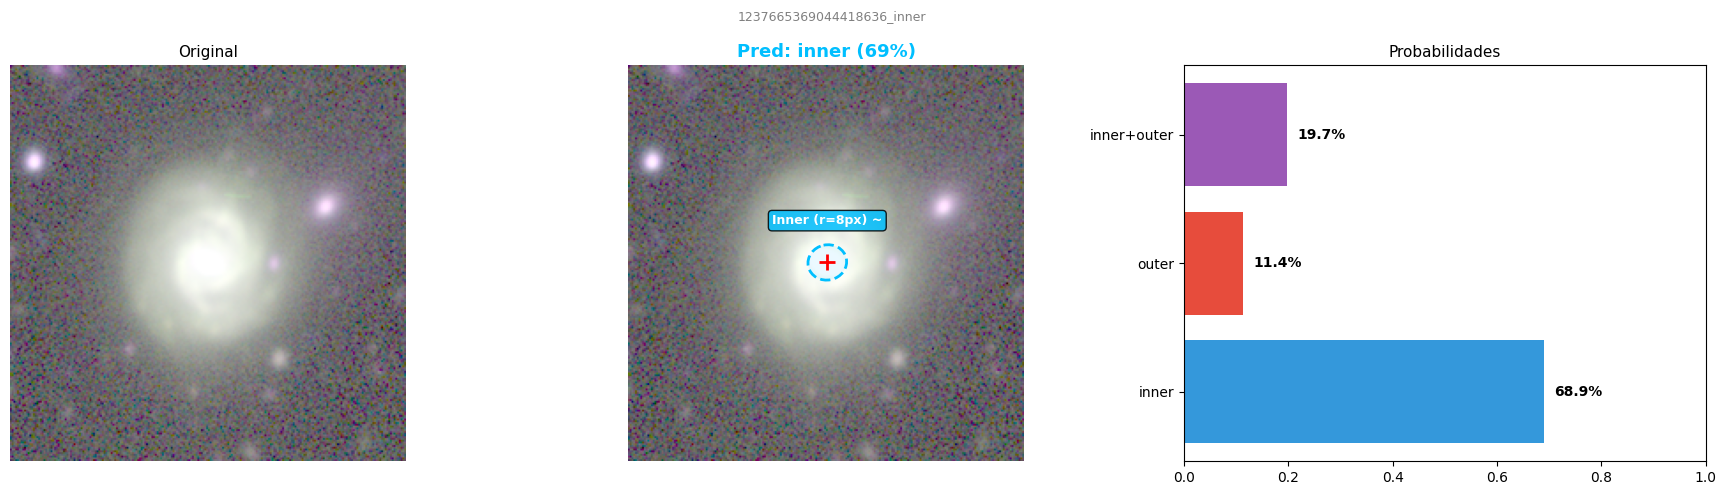

  Inner  (estimado): r=8px


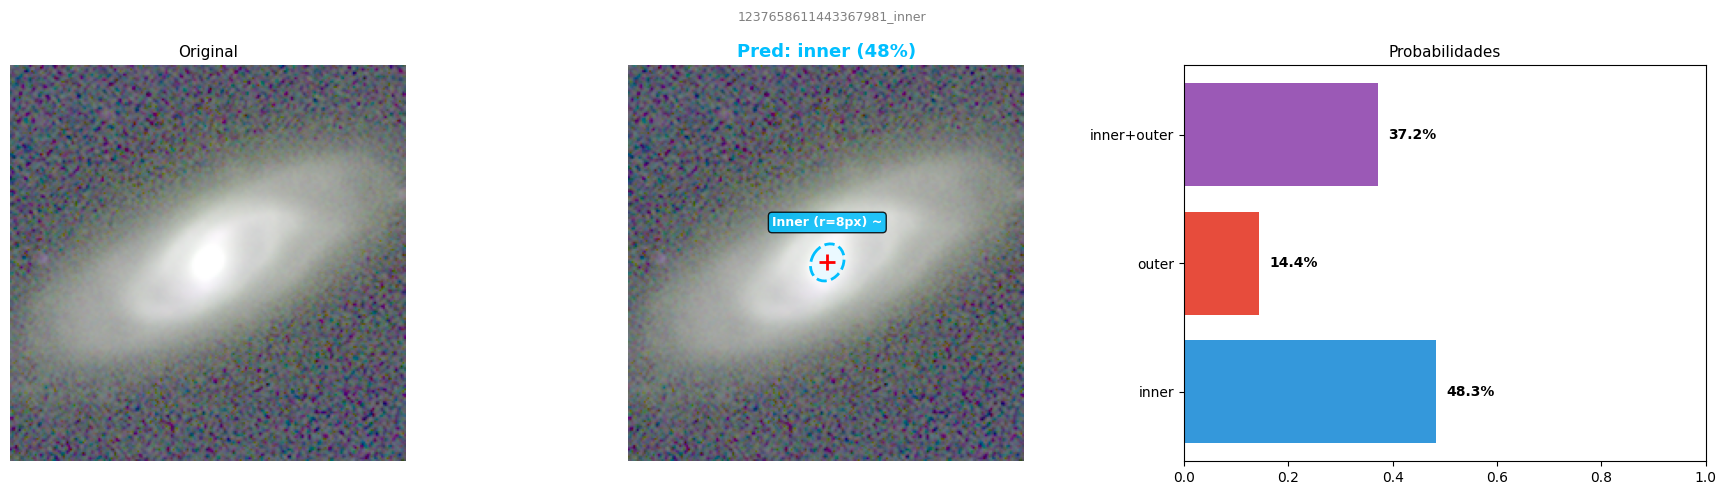

  Inner  (estimado): r=8px

 Clase: OUTER


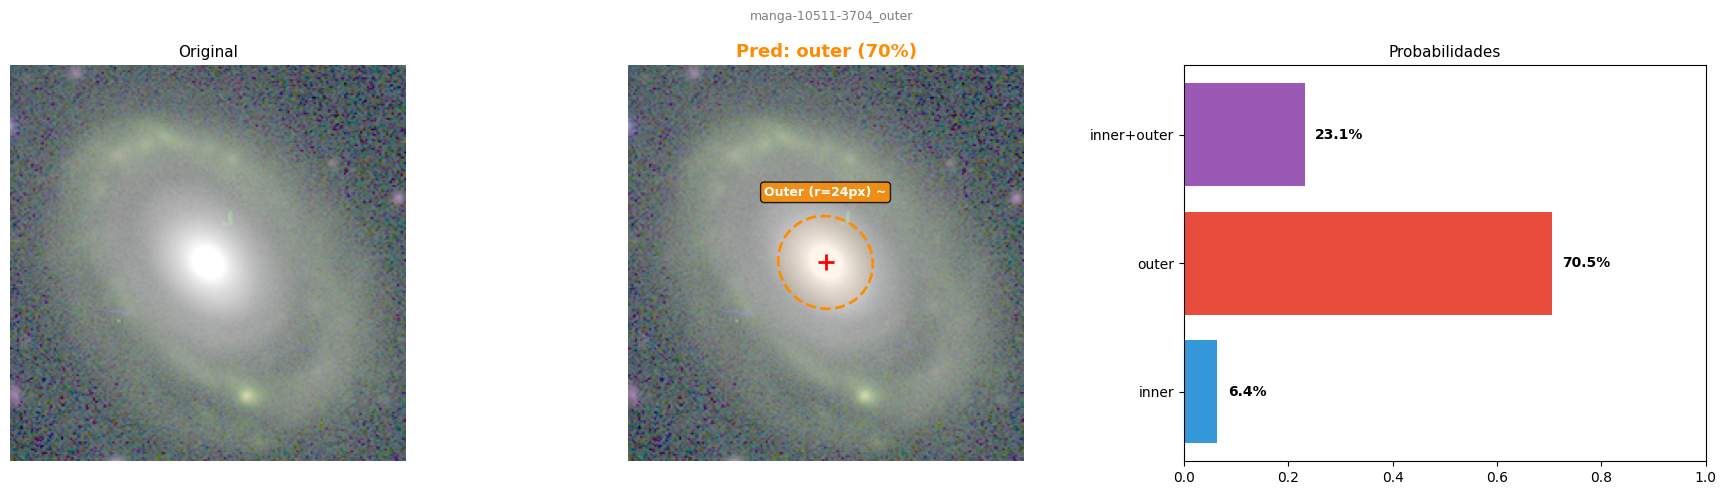

  Outer  (estimado): r=24px


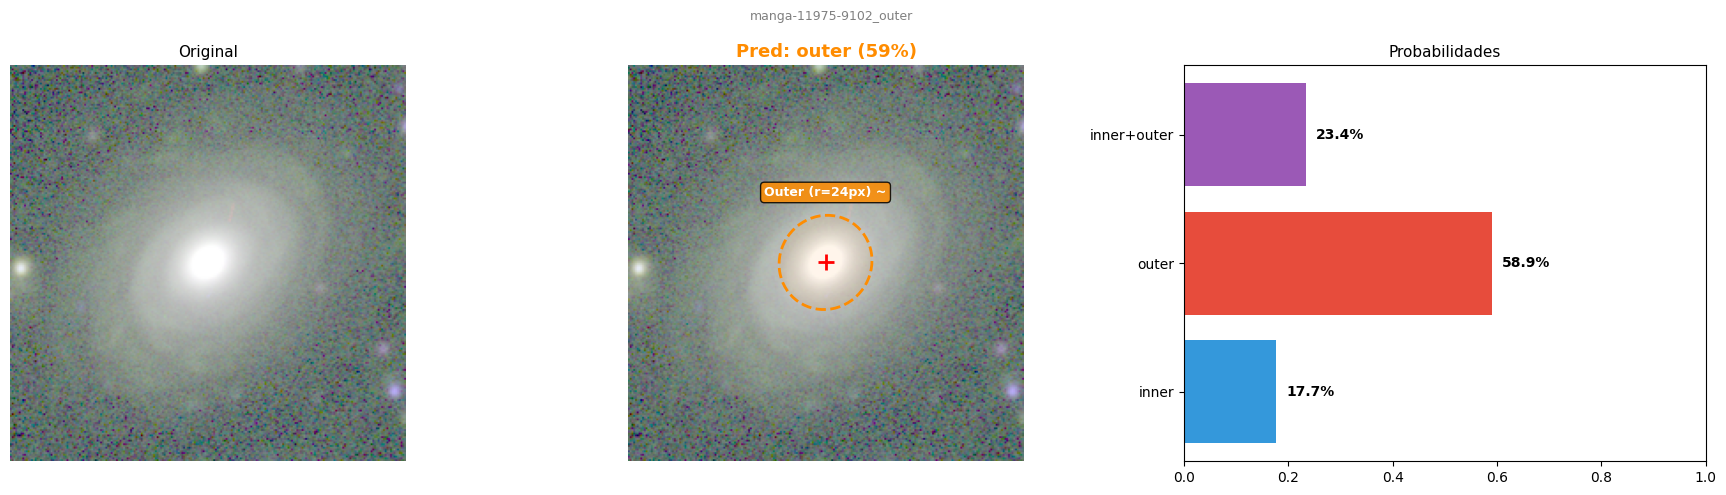

  Outer  (estimado): r=24px


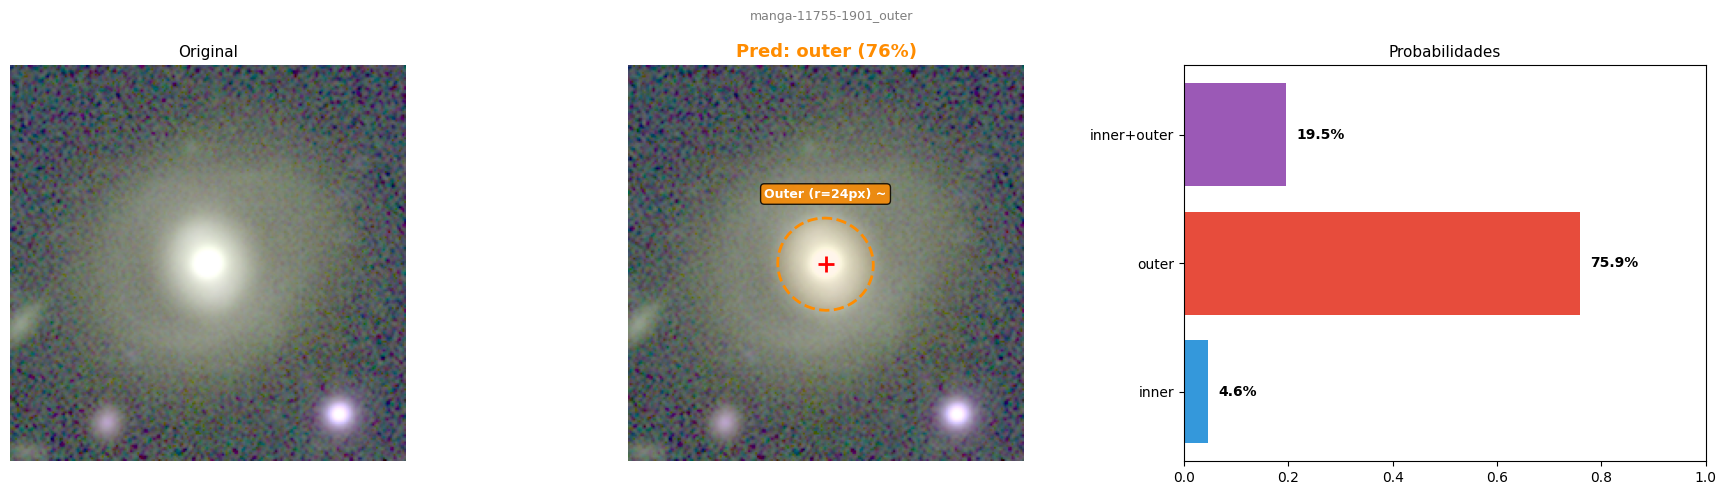

  Outer  (estimado): r=24px

 Clase: INNER+OUTER


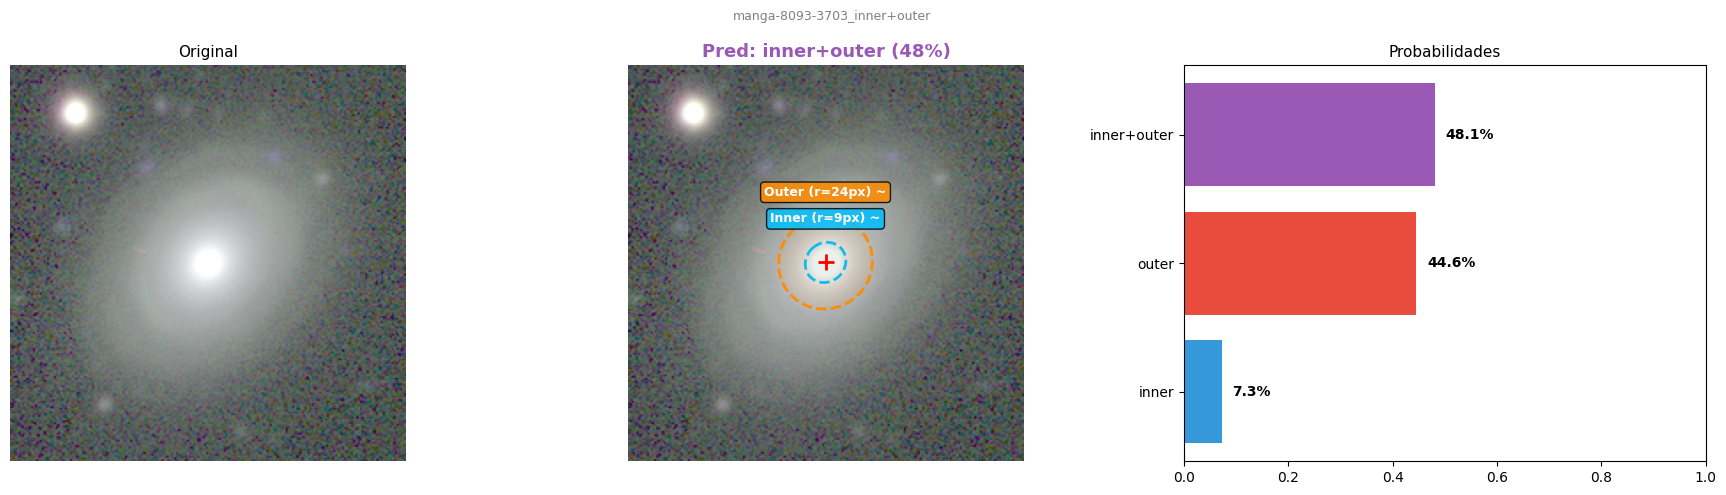

  Inner  (estimado): r=9px
  Outer  (estimado): r=24px


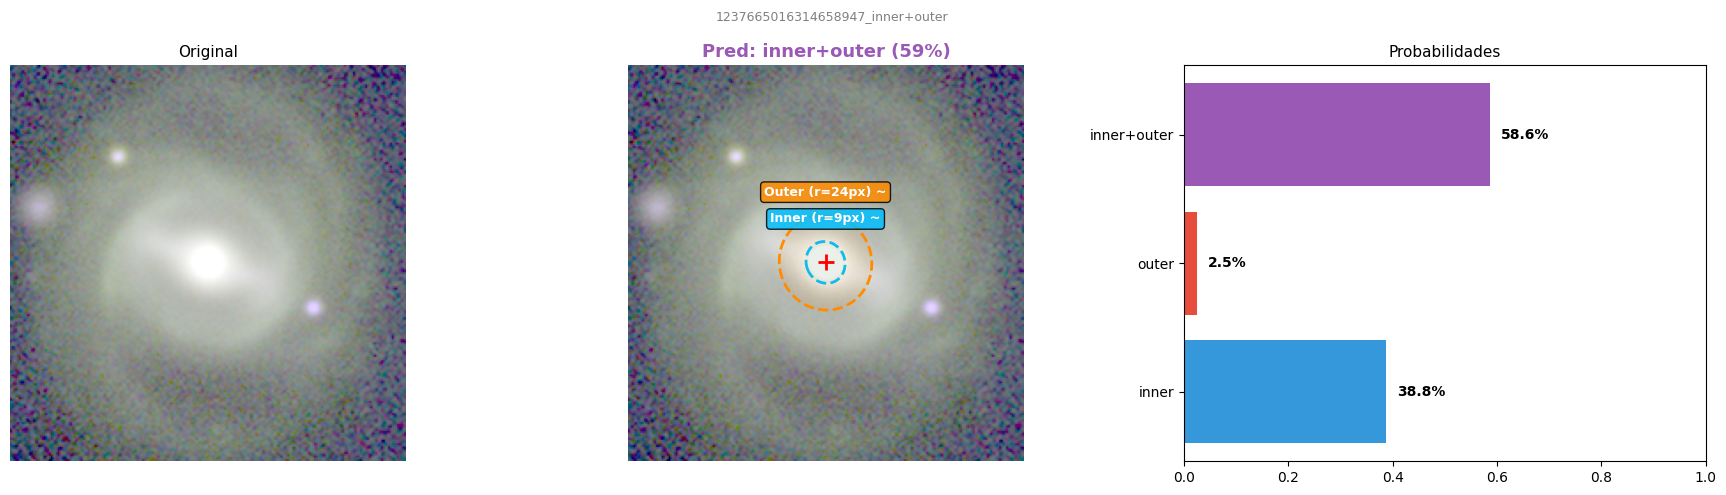

  Inner  (estimado): r=9px
  Outer  (estimado): r=24px


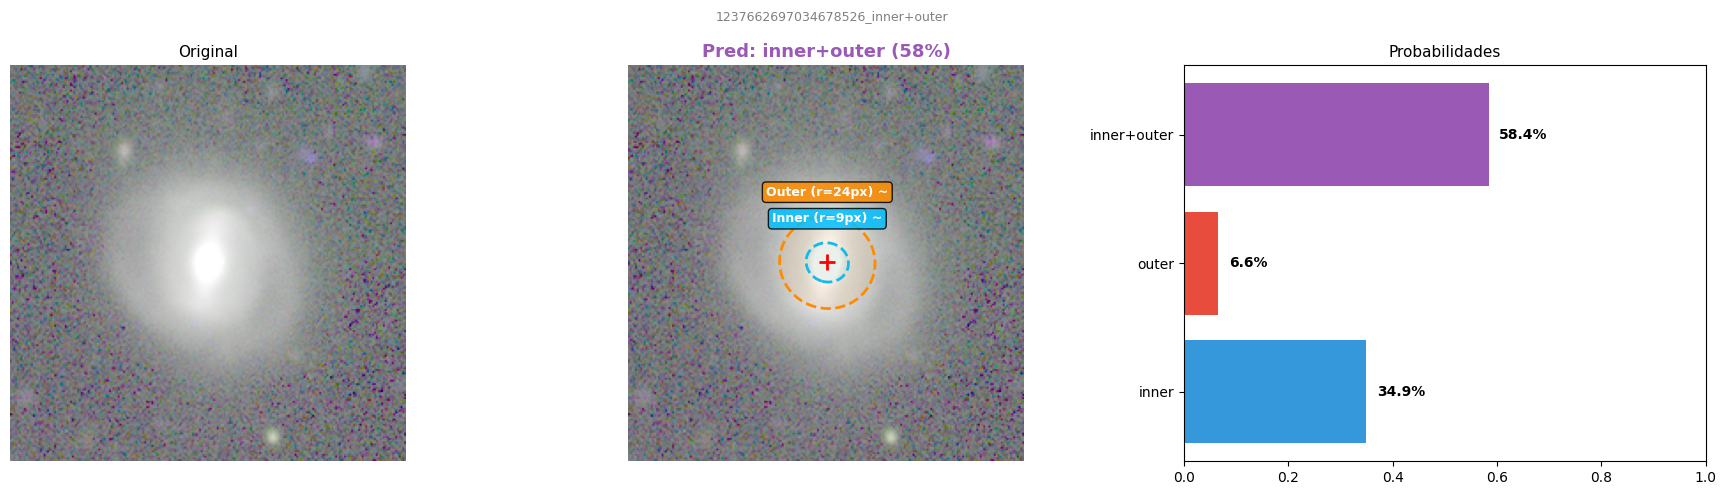

  Inner  (estimado): r=9px
  Outer  (estimado): r=24px


In [21]:
def visualize_galaxy_rings(model, img_path, show_probs=True):
    """Predice clase y dibuja anillos con Ellipse patches."""
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img_rgb = np.array(img)
    tensor = val_transform(img).unsqueeze(0).to(model.device)

    with torch.no_grad():
        output = model(tensor)
        probs = F.softmax(output, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        pred_class = RING_TYPE[pred_idx]
        confidence = probs[pred_idx]

    rings, (cy, cx) = detect_rings_v3(img_rgb, pred_class)
    ring_colors = {'Inner': '#00BFFF', 'Outer': '#FF8C00'}

    ncols = 3 if show_probs else 2
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))

    axes[0].imshow(img_rgb); axes[0].axis('off')
    axes[0].set_title('Original', fontsize=11)

    axes[1].imshow(img_rgb)
    axes[1].plot(cx, cy, 'r+', markersize=12, markeredgewidth=2)
    for ring in rings:
        rtype = ring['type']
        color = ring_colors.get(rtype, '#FFFF00')
        ls = '-' if ring.get('detected', True) else '--'
        lw = 2.5 if ring.get('detected', True) else 2.0
        ep = Ellipse(xy=(cx, cy), width=ring['semi_a'] * 2, height=ring['semi_b'] * 2,
                     angle=-ring['angle'], fill=False, edgecolor=color, linewidth=lw, linestyle=ls)
        axes[1].add_patch(ep)
        ef = Ellipse(xy=(cx, cy), width=ring['semi_a'] * 2, height=ring['semi_b'] * 2,
                     angle=-ring['angle'], fill=True, facecolor=color, alpha=0.08)
        axes[1].add_patch(ef)
        label_y = cy - ring['semi_b'] - 10
        tag = '' if ring.get('detected', True) else ' ~'
        axes[1].annotate(f"{rtype} (r={ring['radius_px']}px){tag}",
                         xy=(cx, max(5, label_y)), fontsize=9, color='white',
                         fontweight='bold', ha='center', va='bottom',
                         bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.85))

    title_color = {'inner': '#00BFFF', 'outer': '#FF8C00', 'inner+outer': '#9b59b6'}
    axes[1].set_title(f'Pred: {pred_class} ({confidence:.0%})', fontsize=13,
                      fontweight='bold', color=title_color.get(pred_class, 'black'))
    axes[1].axis('off')

    if show_probs:
        colors_bar = ['#3498db', '#e74c3c', '#9b59b6']
        bars = axes[2].barh(RING_TYPE, probs, color=colors_bar)
        axes[2].set_xlim(0, 1)
        axes[2].set_title('Probabilidades', fontsize=11)
        for bar, p in zip(bars, probs):
            axes[2].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                         f'{p:.1%}', va='center', fontweight='bold', fontsize=10)

    plt.suptitle(Path(img_path).stem[:40], fontsize=9, color='gray')
    plt.tight_layout()
    plt.show()
    return {'class': pred_class, 'confidence': float(confidence), 'rings': rings}


# Visualizar 3 muestras de cada clase
print('Visualizando muestras con detección de anillos...\n')
for cls_name in RING_TYPE:
    cls_dir = DATA_DIR / cls_name
    imgs = sorted(cls_dir.glob('*.png'))
    if not imgs: continue
    print(f'\n{"="*50}\n Clase: {cls_name.upper()}\n{"="*50}')
    samples = random.sample(imgs, min(3, len(imgs)))
    for img_path in samples:
        result = visualize_galaxy_rings(model, img_path)
        for r in result['rings']:
            det = 'detectado' if r.get('detected', True) else 'estimado'
            print(f'  {r["type"]:6s} ({det}): r={r["radius_px"]}px')

---
# Parte 12: Exportar modelo final

In [22]:
final_path = OUTPUT_DIR / 'zoobot_ring_subclassifier_combined_v8_final.pt'
model.save_model(str(final_path))

# Guardar metadatos del modelo
import json
meta = {
    'model': 'ZoobotRingSubclassifier',
    'version': 'v8_combined',
    'encoder': 'hf_hub:mwalmsley/zoobot-encoder-convnext_nano',
    'classes': RING_TYPE,
    'datasets': ['SDSS DR10 (dataset.csv)', 'MaNGA DR9 (MaNGA_rings.csv)'],
    'n_train': len(df_sdss_rings) + len(df_manga_rings),
    'transform': TRANSFORM,
    'image_size': IMAGE_SIZE,
    'pixscale': PIXSCALE,
}
meta_path = OUTPUT_DIR / 'model_metadata_v8.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Modelo exportado: {final_path}')
print(f'Metadatos:        {meta_path}')
print('\nListo ✓')

Modelo guardado: outputs\zoobot_ring_subclassifier_combined_v8_final.pt
Modelo exportado: outputs\zoobot_ring_subclassifier_combined_v8_final.pt
Metadatos:        outputs\model_metadata_v8.json

Listo ✓
